# FEM Dataset Lookup in SAX Models

::::{admonition} Required extras
:class: tip

This notebook needs the `models` extra:

```bash
uv add "qpdk[models]"
# or, from a checkout of this repository:
uv sync --extra models
# or with pip:
pip install "qpdk[models]"
```

See the {ref}`extras reference <notebook-extras>` for what each extra installs.
::::

Circuit models of superconducting layouts need electrostatic quantities such as
capacitance matrices, which for realistic geometries come from finite-element
(FEM) solvers {cite:p}`jinFiniteElementMethod2014`. One solve takes minutes to
hours, far too slow to call inside a circuit simulation or an optimisation loop.
So a sweep over the design parameters is solved once, stored as a dataset, and
the circuit model interpolates between the stored points.

::::{only} html
:::{mermaid}
flowchart LR
    A["FEM solve<br/>per geometry"] --> B["Sweep over<br/>parameter grid"]
    B --> C["Parquet parts or<br/>Delta table + metadata"]
    C --> D["Dataset.grid<br/>dense array"]
    D --> E["GridInterpolator<br/>jittable lookup"]
    E --> F["SAX model"]
:::
::::

::::{only} typst or typstpdf
A FEM solve per geometry is swept over a parameter grid and stored as Parquet parts or a Delta table carrying its metadata; the dataset is arranged into a dense grid, wrapped in a jittable interpolator, and called from a SAX model.
::::

{mod}`qpdk.models.datasets` stores the results as a long-format
[Polars](https://pola.rs) table with one row per matrix entry. Each Parquet
file (or the Delta table schema) also carries the dataset metadata: units,
terminal and ground conventions, whether the data is synthetic, and free-form
provenance such as the layer stack and solver. A file is therefore
self-describing, and the parameter grid is read off the data rather than
declared separately. Curated datasets ship in the package as Parquet parts in
Git LFS; shared, growing datasets can live in a Delta Lake table on a cloud
bucket.

This notebook inspects the bundled dataset, looks up a capacitance matrix inside
{func}`jax.jit`, and replaces the analytical capacitance of a SAX model with the
lookup.

The bundled data comes from Palace electrostatic solves of the actual QPDK
metal polygons, including their short leads, as perfect conductor sheets on
silicon. A separate coplanar ground frame surrounds the device. The geometry
and mesh settings travel with the data. It covers lengths 40–120 µm, widths
5–20 µm and gaps 4–10 µm; these results apply to that geometry and stack.


In [ ]:
import sys

if "google.colab" in sys.modules:
    import subprocess

    print("Running in Google Colab. Installing QPDK...")
    subprocess.check_call([
        sys.executable,
        "-m",
        "pip",
        "install",
        "-q",
        "qpdk[models] @ git+https://github.com/gdsfactory/quantum-rf-pdk.git",
    ])

In [ ]:
import time
from pathlib import Path

import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np
import polars as pl
import sax
import xarray as xr

from qpdk import logger
from qpdk.models.capacitor import plate_capacitor
from qpdk.models.constants import DEFAULT_FREQUENCY
from qpdk.models.cpw import cpw_z0_from_cross_section
from qpdk.models.datasets import (
    Dataset,
    GridInterpolator,
    check_maxwell,
    maxwell_to_mutual,
)
from qpdk.models.datasets.generate import write
from qpdk.models.datasets.recipe import load_recipe
from qpdk.models.generic import capacitor

## Inspect the dataset

The metadata is read from the files and validated when the dataset opens. The
results table is a plain Polars frame with one row per matrix entry, so it can
be filtered and aggregated without loading anything into JAX.

In [ ]:
dataset = Dataset("plate_capacitor_palace")
metadata = dataset.metadata
logger.info(f"{dataset!r}: synthetic={metadata.synthetic}")
logger.info(f"solver: {metadata.provenance['solver']}")
logger.info(f"extraction settings: {metadata.provenance['settings']}")
logger.info(f"terminals {metadata.terminals} w.r.t. {metadata.reference_ground!r}")
for axis in metadata.axes:
    logger.info(
        f"{axis.name} [{axis.unit}]: validated domain {axis.validated or 'grid span'}"
    )

In [ ]:
dataset.table.head(8)

In [ ]:
(
    dataset
    .scan()
    .filter(pl.col("row") != pl.col("col"))
    .group_by("gap")
    .agg(c_mutual_fF=(-pl.col("value")).mean() * 1e15)
    .sort("gap")
    .collect()
)

## Define a generation recipe

A TOML recipe records the parameter grid and solver settings. It is an input
to generation, not a manifest that must travel with the dataset: the output
Parquet file contains its own units, terminals, solver and geometry provenance.

Start with six geometries before investing in a larger sweep. Paths in the
recipe are relative to the recipe file, so this example keeps its data and
solver runs together. Numeric geometry axes here are in µm; the selected
generator defines their units and the fixed CPW cross-section.

In [ ]:
recipe_path = Path("build/dataset-example/plate-capacitor.toml")
recipe_path.parent.mkdir(parents=True, exist_ok=True)
recipe_path.write_text(
    """generator = "qpdk.models.datasets.plate_capacitor:generate"
output = "coarse"
workdir = "palace-runs"

[grid]
length = [40.0, 80.0]
width = [10.0]
gap = [4.0, 7.0, 10.0]

[palace]
command = ["palace", "-np", "4"]

[palace.settings]
near_mesh = 0.55
domain_pad = 100.0
""",
    encoding="utf-8",
)
recipe = load_recipe(recipe_path)
logger.info(f"Recipe: {recipe.points} geometries, grid={recipe.grid}")
logger.info(
    f"Output: {recipe.output.relative_to(Path.cwd())}; "
    f"retained runs: {recipe.workdir.relative_to(Path.cwd())}"
)

## Run a small sweep and inspect its output

With Palace installed, set `RUN_PALACE = True` below to solve the six
geometries. The default instead selects these six points from the bundled
real Palace results and writes a small dataset, so the entire example also
runs on machines without a solver. This selection performs no new FEM solves.

For MPI or a container, replace the command before running, for example
`recipe = replace(recipe, command=("palace", "-np", "8"))`. A container
command is also an argument tuple; the config filename is appended without a
shell. `--palace-command` provides the same override in the CLI.

In [ ]:
RUN_PALACE = False

if RUN_PALACE:
    generated = recipe.run()
else:
    selection = dataset.table.filter(
        *(pl.col(axis).is_in(values) for axis, values in recipe.grid.items())
    )
    generated = write(recipe.output, dataset.metadata, selection)
    logger.info("Selected existing Palace solves; no simulator was run")

coarse = generated.grid("maxwell_capacitance", cross_section="cpw")
logger.info(
    f"Generated table: {generated.table.height} rows for {recipe.points} geometries"
)
logger.info(
    f"Dense grid: {coarse.values.shape}, terminals={generated.metadata.terminals}"
)

coarse_lookup = GridInterpolator(coarse)
logger.info(
    f"Small-sweep lookup at 60/10/7 µm [fF]:\n"
    f"{coarse_lookup(length=60.0, width=10.0, gap=7.0) * 1e15}"
)

2026-10-06 22:38:48.066 | INFO     | __main__:<module>:10 - Selected existing Palace solves; no simulator was run


2026-10-06 22:38:48.084 | INFO     | __main__:<module>:13 - Generated table: 24 rows for 6 geometries


2026-10-06 22:38:48.084 | INFO     | __main__:<module>:16 - Dense grid: (2, 1, 3, 2, 2), terminals=('o1', 'o2')


2026-10-06 22:38:49.181 | INFO     | __main__:<module>:21 - Small-sweep lookup at 60/10/7 µm [fF]:
[[10.95989723 -3.14768446]
 [-3.14768446 10.96214271]]


A complete two-terminal matrix has four entries per geometry, so this sweep
has 24 rows. Open the result in a separate session with
`Dataset("build/dataset-example/coarse")`; loading and interpolation need no
Palace installation. The table below verifies that every geometry has four
successful entries.

In [ ]:
(
    generated
    .scan()
    .group_by("length", "width", "gap", "status")
    .len(name="matrix_entries")
    .sort("length", "gap")
    .collect()
)

length,width,gap,status,matrix_entries
f64,f64,f64,str,u32
40.0,10.0,4.0,"""ok""",4
40.0,10.0,7.0,"""ok""",4
40.0,10.0,10.0,"""ok""",4
80.0,10.0,4.0,"""ok""",4
80.0,10.0,7.0,"""ok""",4
80.0,10.0,10.0,"""ok""",4


## Generate from the command line and resume

Run the exact recipe from the repository root:

```bash
just generate-dataset build/dataset-example/plate-capacitor.toml --dry-run
just generate-dataset build/dataset-example/plate-capacitor.toml
```

The dry run previews the grid, geometry count, resolved paths and settings
without invoking the solver. Outside a checkout, use
`python -m qpdk.models.datasets.recipe recipe.toml`.
`datasets/plate_capacitor.toml` is the repository's full 27-point recipe.

Run the same command again after an interruption. A geometry directory holds
`inputs.json`, `mesh.msh`, `config.json`, `solver.log` and `result.json`.
Completed matching solves are reused; failed ones run again. Changing the
geometry, mesh, solver fingerprint or thread settings creates a different
directory. The output dataset is replaced only after all solves and validation
succeed. If a solve fails, follow the log path in the error message.

To extend this example, add `120.0` to `length` in the recipe and rerun it:
the six old geometries are reused and only three new ones are solved. Keep
the same work directory. `--output` and `--workdir` can redirect results to
another disk; CLI path overrides are relative to the current directory.

## Check mesh and domain sensitivity

A denser parameter grid improves interpolation, but it cannot repair a coarse
FEM mesh. Before expanding a sweep, compare one representative geometry at
successively finer mesh sizes, then enlarge the exterior domain. The Python
API uses the same recipe as the command line:

```python
center = replace(recipe, grid={"length": [80.0], "width": [10.0], "gap": [7.0]})
matrices = []
for size in [0.8, 0.55, 0.38]:
    refined = replace(
        center,
        output=recipe.output.parent / f"mesh-{size}",
        settings=replace(center.settings, near_mesh=size, save_fields=True),
    )
    solved = refined.run().grid("maxwell_capacitance", cross_section="cpw")
    matrices.append(np.asarray(solved.values).reshape(2, 2))
relative_change = np.max(np.abs((matrices[-1] - matrices[-2]) / matrices[-1]))
logger.info(f"Last mesh refinement changed the matrix by {relative_change:.2%}")
expanded = replace(
    center,
    output=recipe.output.parent / "larger-domain",
    settings=replace(center.settings, domain_pad=150.0),
).run()
```

`save_fields=True` retains each terminal's fields for ParaView. Inspect the
metal edges and gaps where the electric field concentrates. Keep refinement
outputs separate, and check points near both ends of a new geometry range.
The bundled extraction was checked at 80/10/7 µm: its final 0.55-to-0.38 µm
refinement changed matrix entries by at most 0.57%, and enlarging the domain
changed them by 0.25%. Four held-out solves at width 10 µm differed from the
interpolated matrices by at most 2.68%. These checks do not establish a
uniform error bound over every width or an expanded design range.

## Add another dataset generator

A recipe's `generator` is a `module:function`, not a capacitor-specific CLI
option. To extract another geometry, provide an importable function accepting
`runner`, `grid` and `output` keyword arguments. It defines the cell, axes,
units and terminal conventions, then uses {func}`qpdk.models.datasets.generate.sweep`
and {func}`qpdk.models.datasets.generate.write`. The existing
{func}`qpdk.models.datasets.plate_capacitor.generate` is a complete example.
This Palace recipe supports independently ported metal polygons on silicon;
a different process stack or solver needs its own extraction implementation.

## Look up a Maxwell capacitance matrix

For conductors $1, \dots, n$ at potentials $V_j$ above a reference ground, the
charges are linear in the potentials, $Q_i = \sum_j C_{ij} V_j$. The
*Maxwell* capacitance matrix $C$ is what an electrostatic FEM solver returns:
it is symmetric, its diagonal is positive, and its off-diagonal entries are
non-positive. The *mutual* capacitance between conductors $i \neq j$ is
$C^{\text{m}}_{ij} = -C_{ij}$, and the capacitance of conductor $i$ to ground
is the row sum $C^{\text{m}}_{ii} = \sum_j C_{ij}$. The mutual form is what
appears as branch capacitances in a lumped circuit, and the Maxwell form is the
capacitance matrix of circuit quantization
{cite:p}`voolIntroductionQuantumElectromagnetic2017`.
{func}`~qpdk.models.datasets.maxwell_to_mutual` converts between them, and
{func}`~qpdk.models.datasets.check_maxwell` raises if any property above is violated.

Between the solved points the lookup is multilinear: inside the grid cell
containing a query, the result is a weighted mean of the $2^n$ cell corners,
with weights that are products of the 1D linear weights along each axis
{cite:p}`weiserNotePiecewiseLinear1988`. It reproduces the data exactly at grid
points, is continuous everywhere, and needs no tuning. Outside the validated
domain there is no data to weigh, so the result is NaN.

![Rectilinear grid of solved points; a query inside a cell is a weighted mean of the cell corners, a query outside the grid returns NaN](figures/fem-dataset-lookup.svg)

{meth}`~qpdk.models.datasets.Dataset.grid` arranges the table into a dense
`(length, width, gap, 2, 2)` array and raises if a grid point is missing or
failed. Discrete variants such as the cross-section are chosen explicitly
here and never interpolated. {class}`~qpdk.models.datasets.GridInterpolator` wraps
{class}`jax.scipy.interpolate.RegularGridInterpolator` and holds plain JAX
arrays, so it works inside {func}`jax.jit`, {func}`jax.vmap`, and
{func}`jax.grad`.

In [ ]:
grid = dataset.grid("maxwell_capacitance", cross_section="cpw")
c_maxwell = GridInterpolator(grid)
logger.info(repr(c_maxwell))

C = c_maxwell(length=100.0, width=10.0, gap=5.0)
logger.info(f"Maxwell matrix [fF]:\n{np.asarray(C) * 1e15}")
logger.info(f"Mutual matrix [fF]:\n{np.asarray(maxwell_to_mutual(C)) * 1e15}")
check_maxwell(C)  # raises NonPhysicalMatrixError if C is not physical

Outside the validated domain the lookup returns NaN. {func}`sax.interpolate_xarray`
clamps to the nearest edge instead, which hides an out-of-range design.

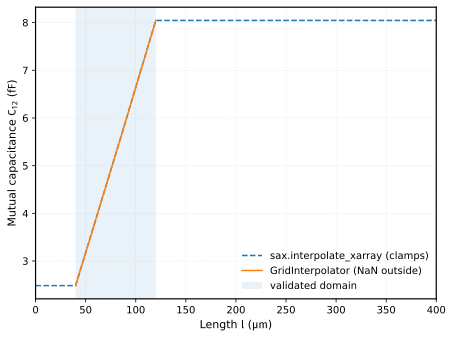

In [ ]:
lengths = jnp.linspace(0.0, 400.0, 401)
ours = -c_maxwell(length=lengths, width=10.0, gap=5.0)[:, 0, 1]

xarr = xr.DataArray(
    grid.values.reshape(*grid.values.shape[:3], 4),
    coords={
        **dict(zip(grid.axis_names, grid.coords, strict=True)),
        "targets": np.array(["c11", "c12", "c21", "c22"], dtype=object),
    },
)
theirs = -jax.vmap(
    lambda length: sax.interpolate_xarray(xarr, length=length, width=10.0, gap=5.0)[
        "c12"
    ]
)(lengths)

fig, ax = plt.subplots()
ax.plot(lengths, theirs * 1e15, "--", label="sax.interpolate_xarray (clamps)")
ax.plot(lengths, ours * 1e15, label="GridInterpolator (NaN outside)")
ax.axvspan(*c_maxwell.domain["length"], alpha=0.1, label="validated domain")
ax.set_xlabel(r"Length $l$ ($\text{µm}$)")
ax.set_ylabel(r"Mutual capacitance $C_{12}$ ($\text{fF}$)")
ax.legend()
plt.show()

## Replace an explicit capacitance in a SAX model

{func}`~qpdk.models.capacitor.plate_capacitor` computes its capacitance from a
closed-form expression. The same circuit can take the mutual capacitance from
the dataset instead. The analytical formula and FEM model include different
geometry and ground assumptions, so their disagreement is visible here. The
lookup uses only the mutual branch; a complete circuit can also include the
extracted pad-to-ground capacitances.

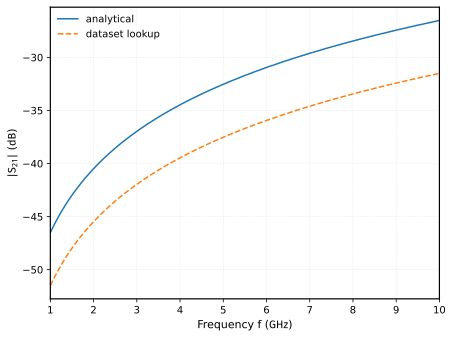

In [ ]:
def plate_capacitor_lookup(
    *,
    f=DEFAULT_FREQUENCY,
    length: float = 80.0,
    width: float = 5.0,
    gap: float = 7.0,
    cross_section="cpw",
) -> sax.SDict:
    """Plate capacitor with the mutual capacitance looked up from the dataset."""
    f = jnp.asarray(f)
    c_mutual = maxwell_to_mutual(c_maxwell(length=length, width=width, gap=gap))[0, 1]
    return capacitor(
        f=f, capacitance=c_mutual, z0=cpw_z0_from_cross_section(cross_section, f)
    )


f = jnp.linspace(1e9, 10e9, 201)
s_lookup = jax.jit(
    lambda gap: plate_capacitor_lookup(f=f, length=80.0, width=10.0, gap=gap)
)(7.0)
s_analytical = plate_capacitor(f=f, length=80.0, width=10.0, gap=7.0)

fig, ax = plt.subplots()
ax.plot(f / 1e9, 20 * np.log10(np.abs(s_analytical["o1", "o2"])), label="analytical")
ax.plot(
    f / 1e9, 20 * np.log10(np.abs(s_lookup["o1", "o2"])), "--", label="dataset lookup"
)
ax.set_xlabel(r"Frequency $f$ ($\text{GHz}$)")
ax.set_ylabel(r"$|S_{21}|$ ($\text{dB}$)")
ax.legend()
plt.show()

The lookup is differentiable, so the gap can be tuned by gradient descent
towards a target transmission.

In [ ]:
d_s21_d_gap = jax.jit(
    jax.grad(
        lambda gap: jnp.abs(
            plate_capacitor_lookup(f=5e9, length=80.0, width=10.0, gap=gap)["o1", "o2"]
        )
    )
)
logger.info(f"d|S21|/d gap at 5 GHz, gap = 7 µm: {float(d_s21_d_gap(7.0)):.3e} 1/µm")

## Compile and query time

Compile time and steady-state query time are measured separately, for a single
point and for a batch of 10 000 points.

In [ ]:
def benchmark(fn, *args, repeats: int = 50) -> tuple[float, float]:
    """Return (compile time, steady-state time per call) in ms."""
    jitted = jax.jit(fn)
    t0 = time.perf_counter()
    jax.block_until_ready(jitted(*args))
    compile_ms = (time.perf_counter() - t0) * 1e3
    t0 = time.perf_counter()
    for _ in range(repeats):
        jax.block_until_ready(jitted(*args))
    return compile_ms, (time.perf_counter() - t0) / repeats * 1e3


rng = np.random.default_rng(0)
batch = {
    name: jnp.asarray(rng.uniform(lo, hi, 10_000))
    for name, (lo, hi) in c_maxwell.domain.items()
}
single = {name: x[0] for name, x in batch.items()}

rows = []
for label, point in [("1 point", single), ("10 000 points", batch)]:
    for method, fn in [
        ("GridInterpolator", lambda p: c_maxwell(**p)[..., 0, 1]),
        ("sax.interpolate_xarray", lambda p: sax.interpolate_xarray(xarr, **p)["c12"]),
    ]:
        compile_ms, query_ms = benchmark(fn, point)
        rows.append({
            "method": method,
            "query": label,
            "compile_ms": compile_ms,
            "query_ms": query_ms,
        })
pl.DataFrame(rows)

## References

```{bibliography}
:filter: docname in docnames
```